HVDC Interconnector 

Here we use a link not a line because we need to actively set the powerflow through the converter stations, which convert AC to DC and back. 

A line would be suited for AC corridors inside meshed networls where loop flows matter.

In [2]:
import pypsa

# add buses
n = pypsa.Network()

n.add("Bus", "zambia", carrier="AC")
n.add("Bus", "zimbabwe", carrier="AC")

# add HVDC as link
n.add("Link", "zambia_zimbabwe", 
      bus0="zambia", bus1="zimbabwe", 
      carrier="HVDC", p_nom=1000, 
      p_min_pu=-1, efficiency=0.95)

# add generators
n.add("Generator", "hydro_zambia", bus="zambia", p_nom=500, marginal_cost=1)
n.add("Generator", "hydro_zimbabwe", bus="zimbabwe", p_nom=500, marginal_cost=1)    

# add loads
n.add("Load", "load_zambia", bus="zambia", p_set=400)
n.add("Load", "load_zimbabwe", bus="zimbabwe", p_set=400)   

# solve the network
n.optimize(solver_name="highs")

ERROR 1: PROJ: proj_create_from_database: Open of /home/mwiche/anaconda3/envs/pypsa-earth/share/proj failed
Index(['zambia', 'zimbabwe'], dtype='object', name='Bus')
Index(['zambia_zimbabwe'], dtype='object', name='Link')
Index(['zambia', 'zimbabwe'], dtype='object', name='Bus')
Index(['zambia_zimbabwe'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 3 primals, 8 duals
Objective: 7.95e+02
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-3kd6lhru has 8 rows; 3 cols; 10 nonzeros
Coefficient ranges:
  Matrix [9e-01, 1e+00]
  Cost   [1e+00, 1e+00]
  Bound  [0e+00, 0e+00]
  RHS    [4e+02, 1e+03]
Presolving model
0 rows, 0 cols, 0 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve : Reductions: rows 0(-8); columns 0(-3); elements 0(-10) - Reduced to empty
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-3kd6lhru
Model status        : Optimal
Objective value     :  7.9473684211e+02
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00
Writing the solution to /tmp/linopy-solve-zd6jt49y.sol


('ok', 'optimal')

/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/mwiche/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:842: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  self.set_ylim([y1, y2])


(<matplotlib.collections.PatchCollection at 0x7685c970c1d0>,
 <matplotlib.collections.LineCollection at 0x7685c4174e90>)

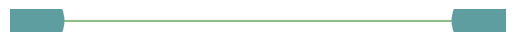

In [3]:
n.plot()

In [4]:
n.pf()

INFO:pypsa.pf:Balancing power on single-bus sub-network SubNetwork 0 for snapshots Index(['now'], dtype='object', name='snapshot')
INFO:pypsa.pf:Balancing power on single-bus sub-network SubNetwork 1 for snapshots Index(['now'], dtype='object', name='snapshot')


{'n_iter': SubNetwork  0  1
 snapshot        
 now         0  0,
 'error': SubNetwork    0    1
 snapshot            
 now         0.0  0.0,
 'converged': SubNetwork     0     1
 snapshot              
 now         True  True}

In [6]:
n.model.to_file("interconnector.lp")

INFO:linopy.io: Writing time: 0.02s


PosixPath('interconnector.lp')